# **Install & Import libraries**

In [2]:
!pip install pypdf
import numpy as np
import networkx as nx

from pypdf import PdfReader

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

from transformers import pipeline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.1/378.1 kB 8.3 MB/s eta 0:00:00


# **Upload your PDF**

In [6]:
from google.colab import files

uploaded = files.upload()

path = list(uploaded.keys())[0]

print("Path of the file:", path)

Saving base model.pdf to base model.pdf
Path of the file: base model.pdf


# **Upload your PDF**

In [8]:
reader = PdfReader(path)

text = ''

for page in reader.pages:

  page_text = page.extract_text()

  if page_text:
    text = page_text + '\n'

In [13]:
print("No of Pages:",len(reader.pages))

No of Pages: 116


# **Chunk the document**

In [16]:
def create_chunk(text, chunk_size = 500, overlap = 100):
  chunks = []
  start = 0

  while start < len(text):
    end = start + chunk_size

    chunks.append(text[start:end])

    start += chunk_size - overlap
  return chunks

In [17]:
chunks = create_chunk(text)

print(len(chunks))

2


# **build the Knowledge Graph**

In [18]:
graph = nx.DiGraph()

In [19]:
graph.add_edge(
    "Python",
    "Machine Learning",
    relation="used_for"
)

graph.add_edge(
    "Google",
    "TensorFlow",
    relation="developed"
)

graph.add_edge(
    "TensorFlow",
    "Deep Learning",
    relation="used_for"
)

In [20]:
for source, target, data in graph.edges(data=True):

    print(
        source,
        "--",
        data["relation"],
        "-->",
        target
    )

Python -- used_for --> Machine Learning
Google -- developed --> TensorFlow
TensorFlow -- used_for --> Deep Learning


# **Adding LLM**

In [22]:
extractor = pipeline(
    "text-generation",
    model="google/flan-t5-base"
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'Cohere2MoeForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DeepseekV32ForCausalLM', 'DeepseekV4ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCaus

In [23]:
test_text = """
Google developed TensorFlow.
TensorFlow is widely used for deep learning.
"""

prompt = f"""
Extract the important entities and relationships from this text.

Text:
{test_text}

Return the result in this format:

Entities:
entity1, entity2, entity3

Relationships:
entity1 | relationship | entity2
"""

In [24]:
entities = [
    "Google",
    "TensorFlow",
    "Deep Learning"
]

In [25]:
relationships = [
    ("Google", "TensorFlow", "developed"),
    ("TensorFlow", "Deep Learning", "used_for")
]

In [26]:
graph.add_edge(
    "Google",
    "TensorFlow",
    relation="developed"
)

graph.add_edge(
    "TensorFlow",
    "Deep Learning",
    relation="used_for"
)

# **Graph Visulazation**

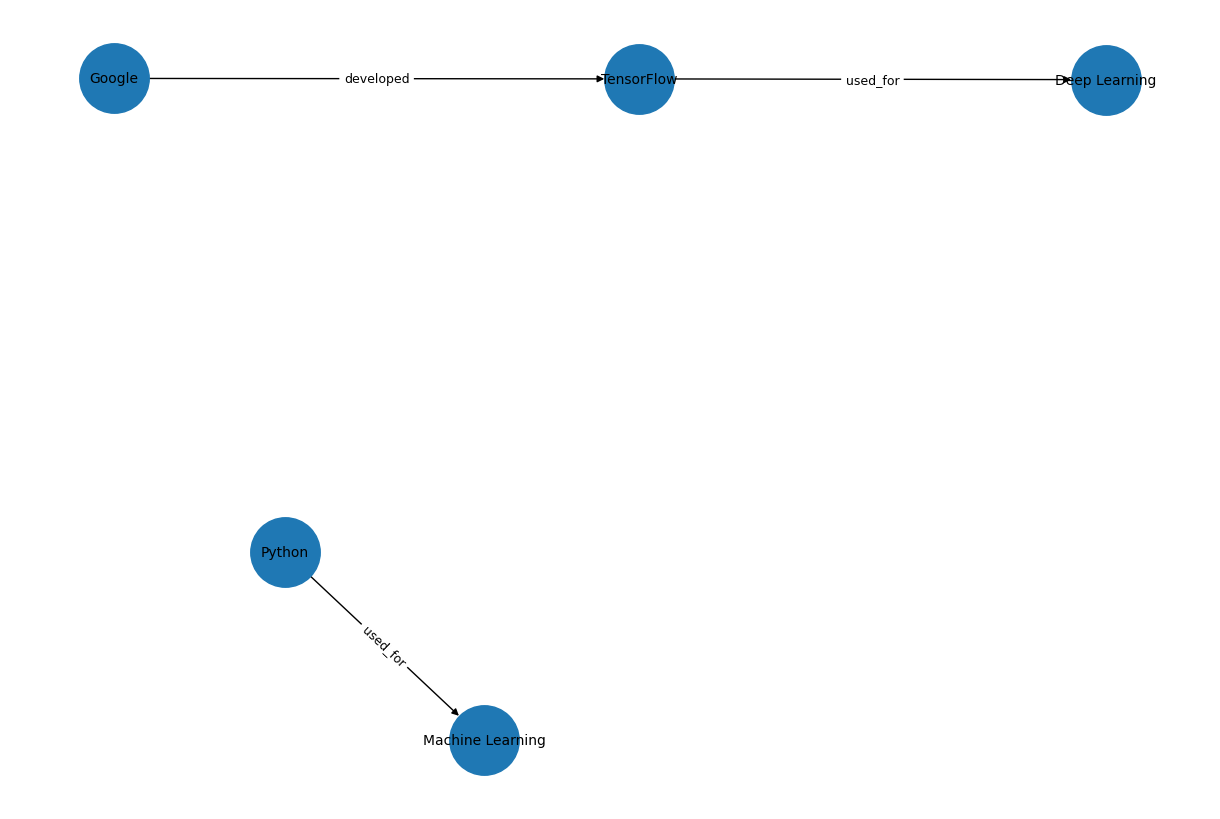

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(graph, seed=42)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=10,
    arrows=True
)

edge_labels = nx.get_edge_attributes(
    graph,
    "relation"
)

nx.draw_networkx_edge_labels(
    graph,
    pos,
    edge_labels=edge_labels,
    font_size=9
)

plt.show()

In [28]:
entity = "Google"

neighbors = graph[entity]

for neighbor, data in neighbors.items():

    print(
        entity,
        "--",
        data["relation"],
        "-->",
        neighbor
    )

Google -- developed --> TensorFlow
